In [1]:
!git clone https://github.com/uzbtrust/Uzbek-Operator-NER-From-Scratch.git
%cd Uzbek-Operator-NER-From-Scratch
!pip install -q seqeval pyyaml datasets

Cloning into 'Uzbek-Operator-NER-From-Scratch'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 78 (delta 26), reused 63 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 155.56 KiB | 1.51 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/kaggle/working/Uzbek-Operator-NER-From-Scratch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os, sys, json, shutil, time, yaml, re
from pathlib import Path
from torch.utils.data import DataLoader, ConcatDataset
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

MERGED_CKPT = "/kaggle/input/models/uzbtrust/uzbek-operator-ner/pytorch/uzbek-operator-name/1/merged_best.pt"
WORD_VOCAB  = "/kaggle/input/datasets/uzbtrust/vocab-json/word_vocab.json"
CHAR_VOCAB  = "/kaggle/input/datasets/uzbtrust/vocab-json/char_vocab.json"
TAG_MAP     = "/kaggle/input/datasets/uzbtrust/tag-map/tag_map.json"

WORKING     = Path("/kaggle/working")
VOCAB_DIR   = WORKING / "vocab"
RAW_DIR     = WORKING / "data" / "raw"
DOMAIN_DIR  = WORKING / "data" / "operator_domain"
CKPT_DIR    = WORKING / "checkpoints"
RESULTS_DIR = WORKING / "results"

for d in [VOCAB_DIR, RAW_DIR, DOMAIN_DIR, CKPT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

shutil.copy(WORD_VOCAB, VOCAB_DIR / "word_vocab.json")
shutil.copy(CHAR_VOCAB, VOCAB_DIR / "char_vocab.json")
shutil.copy(TAG_MAP,    VOCAB_DIR / "tag_map.json")

with open("configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16 = device.type == "cuda"

print(f"\nDevice  : {device}")
print("Vocab files ready")

PyTorch : 2.10.0+cu128
CUDA    : True | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Device  : cuda
Vocab files ready


In [3]:
import sys

sys.argv = ["", "--output_dir", str(RAW_DIR)]
from data.download_datasets import download_conll, download_wikiann

print("Downloading CoNLL-2003...")
download_conll(str(RAW_DIR))

print("\nDownloading WikiANN EN...")
download_wikiann("en", str(RAW_DIR))

print("\nDownloading WikiANN RU...")
download_wikiann("ru", str(RAW_DIR))

print("\nAll datasets downloaded.")
for p in RAW_DIR.glob("**/train.json"):
    with open(p) as f:
        n = len(json.load(f))
    print(f"  {p.parent.name}/train.json : {n:,} samples")

2026-04-06 21:02:10,044 [INFO] Downloading CoNLL-2003 (parquet)...


2026-04-06 21:02:10,652 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
2026-04-06 21:02:10,869 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/conll2003/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 21:02:11,155 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/eriktks/conll2003/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 200 OK"
2026-04-06 21:02:11,356 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/conll2003/tree/refs%2Fconvert%2Fparquet/conll2003%2Ftrain?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-06 21:02:11,586 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/eriktks/conll2003/tree/refs%2Fconvert%2Fparquet/conll2003%2Ftrain?recursive=false&expand=false "HTTP/1.1 200 OK"
2026-04-06 21:02:11,791 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/conll2003/tree/refs%2Fconvert%2F

conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

2026-04-06 21:02:16,972 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/validation/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 21:02:17,167 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/eriktks/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/validation/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 21:02:17,168 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-06 21:02:17,176 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Fvalidation%2F0000.parquet "HTTP/1.1 200 OK"
2026-04-06 21:02:17,185 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Fvalidation%2F0000.parquet "HTTP/1.1 200 OK"


0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

2026-04-06 21:02:42,337 [INFO] Saved 20000 samples to /kaggle/working/data/raw/wikiann_ru/train.json
2026-04-06 21:02:43,077 [INFO] Saved 10000 samples to /kaggle/working/data/raw/wikiann_ru/validation.json
2026-04-06 21:02:43,692 [INFO] Saved 10000 samples to /kaggle/working/data/raw/wikiann_ru/test.json



All datasets downloaded.
  wikiann_en/train.json : 20,000 samples
  wikiann_ru/train.json : 20,000 samples
  conll2003/train.json : 14,041 samples


In [4]:
sys.argv = [
    "",
    "--output_dir", str(DOMAIN_DIR),
    "--n_per_template", "300",
    "--seed", "42",
]

from data.generate_synthetic import main as gen_synthetic
gen_synthetic()

print("\nDomain data distribution:")
for split in ["train", "validation", "test"]:
    with open(DOMAIN_DIR / f"{split}.json") as f:
        data = json.load(f)
    by_lang = {"en": 0, "ru": 0}
    for s in data:
        by_lang[s["lang"]] = by_lang.get(s["lang"], 0) + 1
    misc = sum(1 for s in data for t in s["tags"] if "MISC" in t)
    print(f"  {split:12s}: {len(data):5d} samples | EN={by_lang['en']} RU={by_lang['ru']} | MISC tokens={misc}")

print("\nSample (EN):")
with open(DOMAIN_DIR / "train.json") as f:
    samples = json.load(f)
for s in [x for x in samples if x["lang"] == "en"][:3]:
    print("  " + " ".join(f"[{w}|{t}]" if t != "O" else w for w, t in zip(s["tokens"], s["tags"])))

print("\nSample (RU):")
for s in [x for x in samples if x["lang"] == "ru"][:3]:
    print("  " + " ".join(f"[{w}|{t}]" if t != "O" else w for w, t in zip(s["tokens"], s["tags"])))

2026-04-06 21:02:44,070 [INFO] Generated 6000 EN + 6000 RU = 12000 total samples
2026-04-06 21:02:44,074 [INFO] Split: train=9600, val=1200, test=1200
2026-04-06 21:02:44,179 [INFO] Saved 9600 samples to /kaggle/working/data/operator_domain/train.json
2026-04-06 21:02:44,194 [INFO] Saved 1200 samples to /kaggle/working/data/operator_domain/validation.json
2026-04-06 21:02:44,208 [INFO] Saved 1200 samples to /kaggle/working/data/operator_domain/test.json
2026-04-06 21:02:44,229 [INFO] Entity distribution: MISC=19872, PER=6000, ORG=3000, LOC=2547



Domain data distribution:
  train       :  9600 samples | EN=4833 RU=4767 | MISC tokens=15978
  validation  :  1200 samples | EN=587 RU=613 | MISC tokens=1916
  test        :  1200 samples | EN=580 RU=620 | MISC tokens=1978

Sample (EN):
  Enter [*111*1*2#|B-MISC] on your phone to get [conference|B-MISC] [call|I-MISC]
  Can you tell me about the [Optima|B-MISC] package
  Text [BONUS|B-MISC] to activate [family|B-MISC] [sharing|I-MISC]

Sample (RU):
  Для подключения [мобильный|B-MISC] [интернет|I-MISC] наберите [*105#|B-MISC]
  Отправьте [ОТМЕНА|B-MISC] для подключения [чёрный|B-MISC] [список|I-MISC]
  Как перейти на [Unlimited|B-MISC]


In [5]:
from data.vocab import Vocabulary, CharVocabulary, TagMap
from data.preprocess import NERDataset, collate_batch, load_raw_data

word_vocab = Vocabulary.load(VOCAB_DIR / "word_vocab.json")
char_vocab = CharVocabulary.load(VOCAB_DIR / "char_vocab.json")
tag_map    = TagMap.load(VOCAB_DIR / "tag_map.json")

MAX_SEQ  = cfg["data"]["max_seq_len"]
MAX_WORD = cfg["data"]["max_word_len"]

def make_ds(path):
    return NERDataset(load_raw_data(path), word_vocab, char_vocab, tag_map, MAX_SEQ, MAX_WORD)

domain_train = make_ds(DOMAIN_DIR / "train.json")
domain_val   = make_ds(DOMAIN_DIR / "validation.json")
domain_test  = make_ds(DOMAIN_DIR / "test.json")

conll_train  = make_ds(RAW_DIR / "conll2003" / "train.json")
conll_val    = make_ds(RAW_DIR / "conll2003" / "validation.json")
conll_test   = make_ds(RAW_DIR / "conll2003" / "test.json")

wa_en_train  = make_ds(RAW_DIR / "wikiann_en" / "train.json")
wa_ru_train  = make_ds(RAW_DIR / "wikiann_ru" / "train.json")
wa_ru_val    = make_ds(RAW_DIR / "wikiann_ru" / "validation.json")
wa_ru_test   = make_ds(RAW_DIR / "wikiann_ru" / "test.json")

mixed_train  = ConcatDataset([domain_train, conll_train, wa_en_train, wa_ru_train])
mixed_val    = ConcatDataset([domain_val, conll_val, wa_ru_val])

BS = cfg["training"]["batch_size"]

s1_train_loader = DataLoader(domain_train, batch_size=BS, shuffle=True,  collate_fn=collate_batch, num_workers=2, pin_memory=True)
s1_val_loader   = DataLoader(domain_val,   batch_size=BS, shuffle=False, collate_fn=collate_batch, num_workers=2, pin_memory=True)

s2_train_loader = DataLoader(mixed_train,  batch_size=BS, shuffle=True,  collate_fn=collate_batch, num_workers=4, pin_memory=True)
s2_val_loader   = DataLoader(mixed_val,    batch_size=BS, shuffle=False, collate_fn=collate_batch, num_workers=4, pin_memory=True)

test_loader_en  = DataLoader(conll_test,   batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader_ru  = DataLoader(wa_ru_test,   batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader_dom = DataLoader(domain_test,  batch_size=64, shuffle=False, collate_fn=collate_batch)

print(f"Stage 1 — Domain train : {len(domain_train):>6,}  val: {len(domain_val):,}")
print(f"Stage 2 — Mixed  train : {len(mixed_train):>6,}  val: {len(mixed_val):,}")
print(f"  └ domain   : {len(domain_train):,}")
print(f"  └ conll    : {len(conll_train):,}")
print(f"  └ wikiann_en: {len(wa_en_train):,}")
print(f"  └ wikiann_ru: {len(wa_ru_train):,}")

2026-04-06 21:02:44,381 [INFO] Vocabulary loaded from /kaggle/working/vocab/word_vocab.json: 26715 words
2026-04-06 21:02:44,382 [INFO] Character vocabulary loaded: 602 chars


Stage 1 — Domain train :  9,600  val: 1,200
Stage 2 — Mixed  train : 63,641  val: 14,450
  └ domain   : 9,600
  └ conll    : 14,041
  └ wikiann_en: 20,000
  └ wikiann_ru: 20,000


In [6]:
from model.ner_model import BiLSTMCRF
from training.evaluate import run_evaluation

def build_model():
    return BiLSTMCRF(
        vocab_size   = len(word_vocab),
        num_chars    = len(char_vocab),
        num_tags     = len(tag_map),
        word_dim     = cfg["embeddings"]["word_dim"],
        char_dim     = cfg["embeddings"]["char_dim"],
        char_filters = cfg["embeddings"]["char_filters"],
        char_kernel  = cfg["embeddings"]["char_kernel_size"],
        num_langs    = cfg["model"]["num_langs"],
        lang_dim     = cfg["embeddings"]["lang_dim"],
        hidden_size  = cfg["model"]["hidden_size"],
        num_layers   = cfg["model"]["num_layers"],
        dropout      = cfg["model"]["dropout"],
    )

model = build_model()
base_ckpt = torch.load(MERGED_CKPT, map_location=device, weights_only=False)
model.load_state_dict(base_ckpt["model"])
model.to(device)

total = sum(p.numel() for p in model.parameters())
print(f"Base model loaded: {total:,} parameters")

print("\nBase model performance (before fine-tuning):")
m = run_evaluation(model, test_loader_en, tag_map, device)
print(f"  EN test F1 : {m['overall']['f1']:.4f}")
m = run_evaluation(model, test_loader_ru, tag_map, device)
print(f"  RU test F1 : {m['overall']['f1']:.4f}")
m = run_evaluation(model, test_loader_dom, tag_map, device)
print(f"  Domain F1  : {m['overall']['f1']:.4f}  (MISC detection before fine-tune)")

Base model loaded: 10,911,810 parameters

Base model performance (before fine-tuning):
  EN test F1 : 0.7851
  RU test F1 : 0.8193
  Domain F1  : 0.2204  (MISC detection before fine-tune)


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [7]:
def train_one_epoch(model, loader, optimizer, scaler, grad_clip):
    model.train()
    total_loss, n = 0, 0
    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        char_ids = batch["char_ids"].to(device)
        tag_ids  = batch["tag_ids"].to(device)
        lang_ids = batch["lang_ids"].to(device)
        mask     = batch["mask"].to(device)
        lengths  = batch["lengths"].to(device)

        optimizer.zero_grad()
        if USE_FP16:
            with autocast():
                loss = model(word_ids, char_ids, lang_ids, tag_ids, mask, lengths)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = model(word_ids, char_ids, lang_ids, tag_ids, mask, lengths)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)


def run_stage(model, train_loader, val_loader, max_epochs, lr, patience,
              stage_name, save_path, freeze_word_emb=False):

    if freeze_word_emb:
        for p in model.embedding.word_embedding.parameters():
            p.requires_grad = False
    else:
        for p in model.parameters():
            p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"[{stage_name}] Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)")
    print(f"[{stage_name}] lr={lr}  epochs={max_epochs}  patience={patience}")
    print("-" * 70)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4,
    )
    scheduler    = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
    scaler       = GradScaler() if USE_FP16 else None
    grad_clip    = cfg["training"]["grad_clip"]

    best_f1      = 0.0
    patience_cnt = 0
    history      = []

    for epoch in range(max_epochs):
        t0       = time.time()
        avg_loss = train_one_epoch(model, train_loader, optimizer, scaler, grad_clip)
        elapsed  = time.time() - t0

        val_m    = run_evaluation(model, val_loader, tag_map, device)
        val_f1   = val_m["overall"]["f1"]
        val_p    = val_m["overall"]["precision"]
        val_r    = val_m["overall"]["recall"]

        scheduler.step(val_f1)
        lr_now = optimizer.param_groups[0]["lr"]

        history.append({"epoch": epoch+1, "loss": round(avg_loss,4),
                        "val_f1": round(val_f1,4), "val_p": round(val_p,4),
                        "val_r": round(val_r,4), "lr": lr_now})

        marker = ""
        if val_f1 > best_f1:
            best_f1      = val_f1
            patience_cnt = 0
            torch.save({"epoch": epoch, "best_f1": best_f1, "model": model.state_dict()}, save_path)
            marker = "  ✓ best"
        else:
            patience_cnt += 1

        print(f"  Epoch {epoch+1:02d}/{max_epochs} | loss: {avg_loss:.4f} | "
              f"val_f1: {val_f1:.4f} | P: {val_p:.4f} R: {val_r:.4f} | "
              f"lr: {lr_now:.2e} | {elapsed:.0f}s{marker}")

        if patience_cnt >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    print(f"\n[{stage_name}] Best val F1: {best_f1:.4f}")
    return best_f1, history

In [8]:
s1_best_f1, s1_history = run_stage(
    model         = model,
    train_loader  = s1_train_loader,
    val_loader    = s1_val_loader,
    max_epochs    = 25,
    lr            = 5e-5,
    patience      = 6,
    stage_name    = "Stage 1: Domain",
    save_path     = CKPT_DIR / "stage1_domain_best.pt",
    freeze_word_emb = True,
)

[Stage 1: Domain] Trainable: 2,897,310 / 10,911,810 (26.6%)
[Stage 1: Domain] lr=5e-05  epochs=25  patience=6
----------------------------------------------------------------------


/tmp/ipykernel_24/4039015962.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler() if USE_FP16 else None
/tmp/ipykernel_24/4039015962.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 01/25 | loss: 7.2772 | val_f1: 0.7134 | P: 0.7673 R: 0.6665 | lr: 5.00e-05 | 8s  ✓ best
  Epoch 02/25 | loss: 1.8402 | val_f1: 0.9267 | P: 0.9395 R: 0.9143 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 03/25 | loss: 0.8445 | val_f1: 0.9837 | P: 0.9880 R: 0.9795 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 04/25 | loss: 0.4134 | val_f1: 0.9953 | P: 0.9966 R: 0.9940 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 05/25 | loss: 0.2142 | val_f1: 0.9977 | P: 0.9983 R: 0.9970 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 06/25 | loss: 0.1356 | val_f1: 0.9996 | P: 0.9996 R: 0.9996 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 07/25 | loss: 0.0862 | val_f1: 1.0000 | P: 1.0000 R: 1.0000 | lr: 5.00e-05 | 7s  ✓ best
  Epoch 08/25 | loss: 0.0614 | val_f1: 1.0000 | P: 1.0000 R: 1.0000 | lr: 5.00e-05 | 7s
  Epoch 09/25 | loss: 0.0467 | val_f1: 1.0000 | P: 1.0000 R: 1.0000 | lr: 5.00e-05 | 7s
  Epoch 10/25 | loss: 0.0330 | val_f1: 1.0000 | P: 1.0000 R: 1.0000 | lr: 5.00e-05 | 7s
  Epoch 11/25 | loss: 0.0277 | val_f1: 1.0000 | P: 1.0000 R: 1.0

In [9]:
best_s1 = torch.load(CKPT_DIR / "stage1_domain_best.pt", map_location=device, weights_only=False)
model.load_state_dict(best_s1["model"])
print("Loaded Stage 1 best checkpoint for Stage 2")

s2_best_f1, s2_history = run_stage(
    model         = model,
    train_loader  = s2_train_loader,
    val_loader    = s2_val_loader,
    max_epochs    = 50,
    lr            = 1e-5,
    patience      = 8,
    stage_name    = "Stage 2: Mixed",
    save_path     = CKPT_DIR / "stage2_mixed_best.pt",
    freeze_word_emb = False,
)

Loaded Stage 1 best checkpoint for Stage 2
[Stage 2: Mixed] Trainable: 10,911,810 / 10,911,810 (100.0%)
[Stage 2: Mixed] lr=1e-05  epochs=50  patience=8
----------------------------------------------------------------------


/tmp/ipykernel_24/4039015962.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler() if USE_FP16 else None
/tmp/ipykernel_24/4039015962.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 01/50 | loss: 1.4918 | val_f1: 0.8264 | P: 0.8304 R: 0.8225 | lr: 1.00e-05 | 102s  ✓ best
  Epoch 02/50 | loss: 0.6083 | val_f1: 0.8385 | P: 0.8467 R: 0.8305 | lr: 1.00e-05 | 102s  ✓ best
  Epoch 03/50 | loss: 0.5127 | val_f1: 0.8419 | P: 0.8490 R: 0.8349 | lr: 1.00e-05 | 104s  ✓ best
  Epoch 04/50 | loss: 0.4705 | val_f1: 0.8423 | P: 0.8509 R: 0.8339 | lr: 1.00e-05 | 103s  ✓ best
  Epoch 05/50 | loss: 0.4362 | val_f1: 0.8452 | P: 0.8552 R: 0.8354 | lr: 1.00e-05 | 103s  ✓ best
  Epoch 06/50 | loss: 0.4187 | val_f1: 0.8457 | P: 0.8550 R: 0.8367 | lr: 1.00e-05 | 103s  ✓ best
  Epoch 07/50 | loss: 0.4008 | val_f1: 0.8457 | P: 0.8563 R: 0.8354 | lr: 1.00e-05 | 103s  ✓ best
  Epoch 08/50 | loss: 0.3864 | val_f1: 0.8457 | P: 0.8567 R: 0.8350 | lr: 1.00e-05 | 103s
  Epoch 09/50 | loss: 0.3754 | val_f1: 0.8471 | P: 0.8581 R: 0.8364 | lr: 1.00e-05 | 103s  ✓ best
  Epoch 10/50 | loss: 0.3715 | val_f1: 0.8463 | P: 0.8565 R: 0.8363 | lr: 1.00e-05 | 103s
  Epoch 11/50 | loss: 0.3576 | val_f

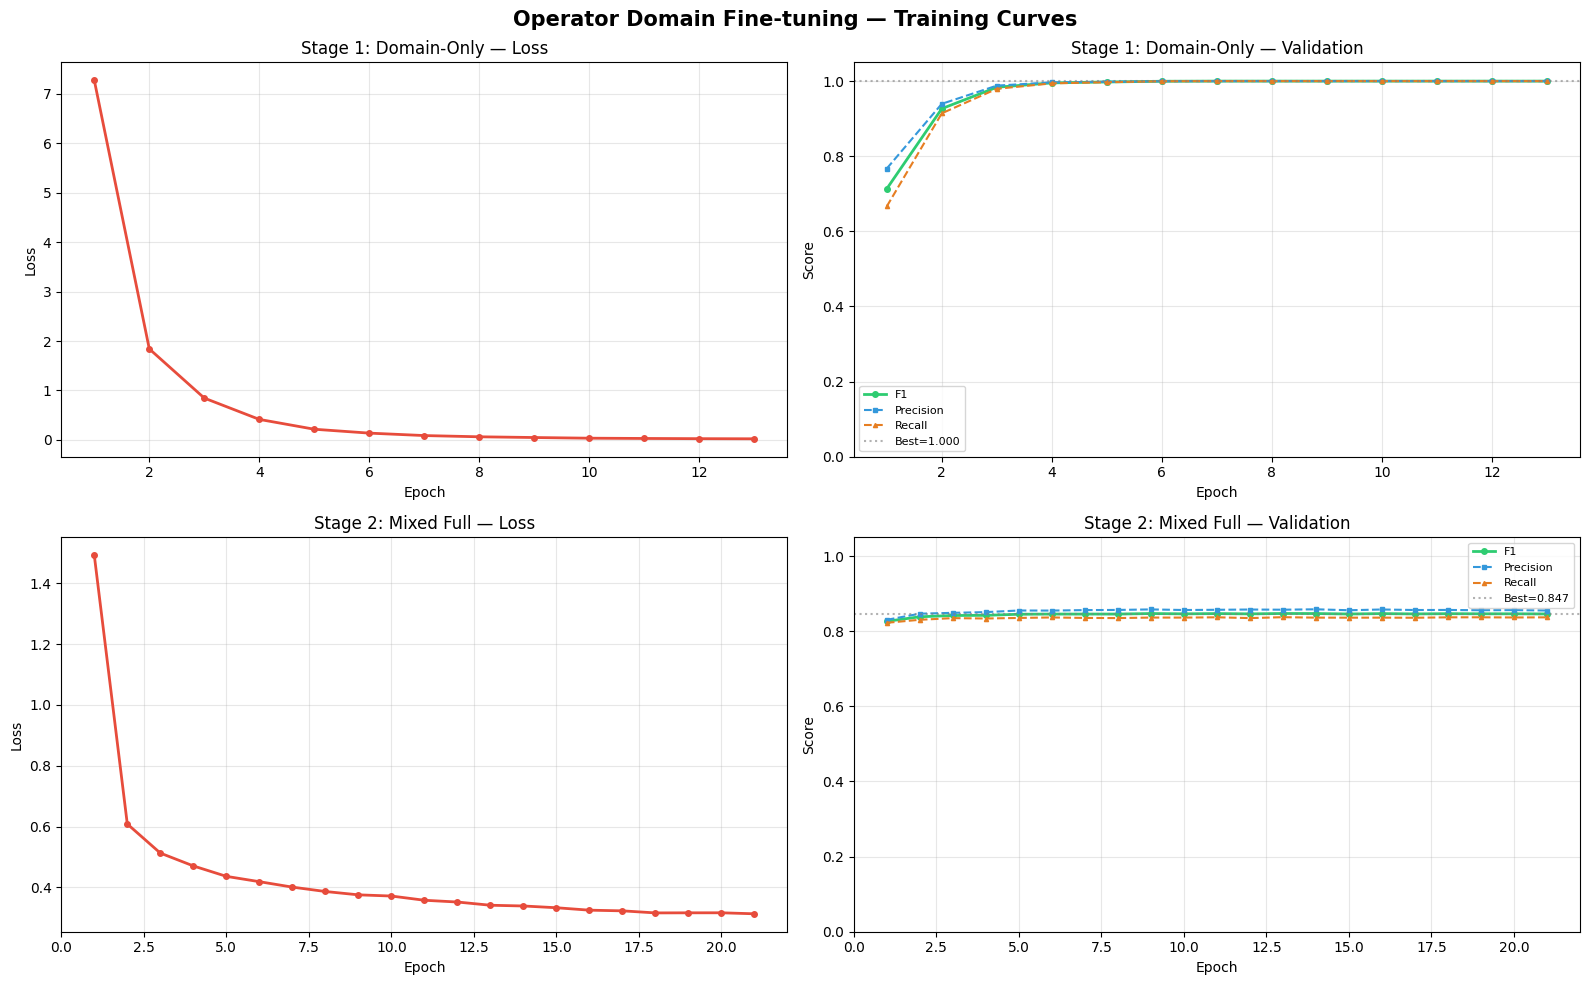

Saved


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Operator Domain Fine-tuning — Training Curves", fontsize=15, fontweight="bold")

for idx, (hist, title) in enumerate([
    (s1_history, "Stage 1: Domain-Only"),
    (s2_history, "Stage 2: Mixed Full"),
]):
    epochs = [h["epoch"]  for h in hist]
    losses = [h["loss"]   for h in hist]
    f1s    = [h["val_f1"] for h in hist]
    precs  = [h["val_p"]  for h in hist]
    recs   = [h["val_r"]  for h in hist]

    ax_loss = axes[idx][0]
    ax_loss.plot(epochs, losses, "o-", color="#e74c3c", linewidth=2, markersize=4)
    ax_loss.set_title(f"{title} — Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(alpha=0.3)

    ax_f1 = axes[idx][1]
    ax_f1.plot(epochs, f1s,   "o-",  color="#2ecc71", linewidth=2,   markersize=4, label="F1")
    ax_f1.plot(epochs, precs, "s--", color="#3498db", linewidth=1.5, markersize=3, label="Precision")
    ax_f1.plot(epochs, recs,  "^--", color="#e67e22", linewidth=1.5, markersize=3, label="Recall")
    best_f1_val = max(f1s)
    ax_f1.axhline(y=best_f1_val, color="gray", linestyle=":", alpha=0.6, label=f"Best={best_f1_val:.3f}")
    ax_f1.set_title(f"{title} — Validation")
    ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylabel("Score")
    ax_f1.set_ylim(0, 1.05)
    ax_f1.legend(fontsize=8)
    ax_f1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "domain_finetune_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

In [11]:
best_s2 = torch.load(CKPT_DIR / "stage2_mixed_best.pt", map_location=device, weights_only=False)
model.load_state_dict(best_s2["model"])

metrics_en  = run_evaluation(model, test_loader_en,  tag_map, device)
metrics_ru  = run_evaluation(model, test_loader_ru,  tag_map, device)
metrics_dom = run_evaluation(model, test_loader_dom, tag_map, device)

print("=" * 60)
print("FINAL MODEL — TEST RESULTS")
print("=" * 60)
print(f"{'Dataset':<20} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 50)
for name, m in [("CoNLL-2003 (EN)", metrics_en), ("WikiANN (RU)", metrics_ru), ("Operator Domain", metrics_dom)]:
    o = m["overall"]
    print(f"{name:<20} {o['f1']:>8.4f} {o['precision']:>10.4f} {o['recall']:>8.4f}")

print()
print("Per-entity (Operator Domain):")
print(f"  {'Entity':<8} {'P':>8} {'R':>8} {'F1':>8} {'Support':>8}")
print("  " + "-" * 38)
for ent, vals in sorted(metrics_dom["per_entity"].items()):
    print(f"  {ent:<8} {vals['precision']:>8.3f} {vals['recall']:>8.3f} {vals['f1-score']:>8.3f} {vals['support']:>8}")

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


FINAL MODEL — TEST RESULTS
Dataset                    F1  Precision   Recall
--------------------------------------------------
CoNLL-2003 (EN)        0.7859     0.8112   0.7622
WikiANN (RU)           0.8172     0.8235   0.8110
Operator Domain        1.0000     1.0000   1.0000

Per-entity (Operator Domain):
  Entity          P        R       F1  Support
  --------------------------------------
  LOC         1.000    1.000    1.000      247
  MISC        1.000    1.000    1.000     1484
  ORG         1.000    1.000    1.000      303
  PER         1.000    1.000    1.000      289


In [12]:
CYRILLIC_RE = re.compile(r"[\u0400-\u04FF]")
LANG_MAP    = {"en": 0, "ru": 1}

def predict(text):
    tokens   = text.strip().split()
    lang     = "ru" if len(CYRILLIC_RE.findall(text)) > len(tokens) * 0.3 else "en"
    lang_id  = LANG_MAP[lang]
    mwl      = cfg["data"]["max_word_len"]
    lowered  = [t.lower() for t in tokens]

    word_ids = torch.tensor([[word_vocab.encode(t) for t in lowered]], dtype=torch.long).to(device)
    char_ids = torch.tensor([[char_vocab.encode_word(t, mwl) for t in lowered]], dtype=torch.long).to(device)
    lang_ids = torch.tensor([lang_id], dtype=torch.long).to(device)
    mask     = torch.ones(1, len(tokens), dtype=torch.float).to(device)
    lengths  = torch.tensor([len(tokens)], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        pred_ids = model.predict(word_ids, char_ids, lang_ids, mask, lengths)

    tags = [tag_map.decode(pred_ids[0][i].item()) for i in range(len(tokens))]
    return list(zip(tokens, tags)), lang

def extract_entities(text):
    tagged, lang = predict(text)
    entities, cur_type, cur_toks = [], None, []
    for tok, tag in tagged:
        if tag.startswith("B-"):
            if cur_type: entities.append((cur_type, " ".join(cur_toks)))
            cur_type, cur_toks = tag[2:], [tok]
        elif tag.startswith("I-") and cur_type == tag[2:]:
            cur_toks.append(tok)
        else:
            if cur_type: entities.append((cur_type, " ".join(cur_toks)))
            cur_type, cur_toks = None, []
    if cur_type: entities.append((cur_type, " ".join(cur_toks)))
    return entities, lang

test_sentences = [
    "Activate the Unlimited tariff by dialing *100#",
    "Send BALANCE to get account info",
    "John Smith from MegaFon called about the Gold plan in London",
    "Dial *555# to subscribe to the Platinum package",
    "Can I enable mobile internet and call forwarding together",
    "Я хочу подключить тариф Premium отправив СТАРТ на *111#",
    "Подключите мне мобильный интернет и голосовую почту",
    "Иван Петров из МегаФон спросил о тарифе Unlimited в Москве",
    "Отправьте БАЛАНС чтобы узнать остаток",
    "Наберите *100# для проверки тарифа Family",
]

print("=" * 65)
print("OPERATOR DOMAIN NER — INFERENCE")
print("=" * 65)

for text in test_sentences:
    entities, lang = extract_entities(text)
    print(f"\n[{lang.upper()}] {text}")
    if entities:
        for etype, etext in entities:
            print(f"       → [{etype:4s}] {etext}")
    else:
        print("       → (no entities)")

OPERATOR DOMAIN NER — INFERENCE

[EN] Activate the Unlimited tariff by dialing *100#
       → [MISC] Unlimited tariff
       → [MISC] *100#

[EN] Send BALANCE to get account info
       → (no entities)

[EN] John Smith from MegaFon called about the Gold plan in London
       → [PER ] John Smith
       → [ORG ] MegaFon
       → [MISC] Gold
       → [LOC ] London

[EN] Dial *555# to subscribe to the Platinum package
       → [MISC] *555#
       → [ORG ] subscribe
       → [MISC] Platinum

[EN] Can I enable mobile internet and call forwarding together
       → [MISC] mobile internet
       → [MISC] call forwarding

[RU] Я хочу подключить тариф Premium отправив СТАРТ на *111#
       → [MISC] Premium
       → [MISC] СТАРТ
       → [MISC] *111#

[RU] Подключите мне мобильный интернет и голосовую почту
       → [MISC] мобильный интернет
       → [MISC] голосовую почту

[RU] Иван Петров из МегаФон спросил о тарифе Unlimited в Москве
       → [PER ] Иван Петров
       → [MISC] Unlimited
       

In [13]:
results = {
    "stage_1_domain": {
        "best_val_f1": round(s1_best_f1, 4),
        "epochs_trained": len(s1_history),
        "lr": 5e-5,
        "freeze_word_emb": True,
        "history": s1_history,
    },
    "stage_2_mixed": {
        "best_val_f1": round(s2_best_f1, 4),
        "epochs_trained": len(s2_history),
        "lr": 1e-5,
        "freeze_word_emb": False,
        "history": s2_history,
    },
    "test_en": {
        "overall": metrics_en["overall"],
        "per_entity": metrics_en["per_entity"],
    },
    "test_ru": {
        "overall": metrics_ru["overall"],
        "per_entity": metrics_ru["per_entity"],
    },
    "test_domain": {
        "overall": metrics_dom["overall"],
        "per_entity": metrics_dom["per_entity"],
    },
}

with open(RESULTS_DIR / "domain_finetune_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Output files:")
for fp in sorted(WORKING.glob("**/*")):
    if fp.is_file() and fp.suffix in (".pt", ".json", ".png"):
        kb = fp.stat().st_size / 1024
        print(f"  {str(fp.relative_to(WORKING)):<55} {kb:>8.1f} KB")

Output files:
  checkpoints/stage1_domain_best.pt                        42630.6 KB
  checkpoints/stage2_mixed_best.pt                         42630.5 KB
  data/operator_domain/test.json                             313.1 KB
  data/operator_domain/train.json                           2519.5 KB
  data/operator_domain/validation.json                       315.3 KB
  data/raw/conll2003/test.json                              1410.0 KB
  data/raw/conll2003/train.json                             6117.0 KB
  data/raw/conll2003/validation.json                        1523.6 KB
  data/raw/wikiann_en/test.json                             2807.8 KB
  data/raw/wikiann_en/train.json                            5606.2 KB
  data/raw/wikiann_en/validation.json                       2812.8 KB
  data/raw/wikiann_ru/test.json                             2901.5 KB
  data/raw/wikiann_ru/train.json                            5775.5 KB
  data/raw/wikiann_ru/validation.json                       2876.2 KB
  resu